<a href="https://colab.research.google.com/github/Akira006/noise-aware-federated-learning-dr/blob/main/Notebook/BasePaper/basepaper_centralized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Base Paper Replication — Centralized Training
**Reference:** Mohan Raj, Morley, Eslami (2024). *Federated Learning for Diabetic Retinopathy Diagnosis.* arXiv:2411.00869

**Setup sesuai base paper:**
- Model: EfficientNetB0 (ImageNet pretrained)
- Optimizer: SGD + momentum (lr=0.001) — bukan Adam
- Training: DDR + EyePACS (pooled) sebagai centralized training set
- Test: DDR test split (in-distribution) + APTOS (cross-institutional, unseen)
- APTOS degraded: JPEG compression quality 30-50 (sesuai base paper)
- Split: 90:10 (train:test) per dataset training
- No class weights — sesuai base paper

> **Catatan:** Ini adalah replication/comparison notebook.
> Paper lo sendiri (exp1/exp2/exp3) pakai setup berbeda yang lebih rigorous.

## 1. GPU Check

In [1]:
!nvidia-smi

Sat May  9 07:09:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   34C    P0             51W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Imports

In [3]:
import os, json, random, time, gc, warnings, io
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score, roc_curve, auc,
    cohen_kappa_score
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetB0

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4. Configuration

In [4]:
# ── REPRODUCIBILITY ───────────────────────────────────────────────
SEED            = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── MODEL ─────────────────────────────────────────────────────────
MODEL_NAME      = "BasePaper_EfficientNetB0"
EXPERIMENT_NAME = "centralized_basepaper"

# ── TRAINING (sesuai base paper) ──────────────────────────────────
IMG_SIZE        = (224, 224)
NUM_CLASSES     = 5
BATCH_SIZE      = 32
LR              = 0.001          # SGD lr — base paper
MOMENTUM        = 0.9            # SGD momentum — base paper
EPOCHS          = 90             # base paper training epochs (dengan EarlyStopping)
UNFREEZE_N      = 10
DROPOUT         = 0.4
L2              = 1e-4
PATIENCE        = 10             # base paper pakai patience lebih besar

# ── SPLIT (sesuai base paper: 90:10) ─────────────────────────────
TRAIN_RATIO     = 0.90
TEST_RATIO      = 0.10

# ── NOISE: JPEG compression (sesuai base paper) ───────────────────
# Base paper: APTOS di-degrade dengan JPEG compression quality 30-50
JPEG_QUALITY_MIN = 30
JPEG_QUALITY_MAX = 50

# ── DATASET ROLES (sesuai base paper) ────────────────────────────
# DDR + EyePACS → training institutions
# APTOS → unseen cross-institutional test (clean + JPEG degraded)
TRAIN_CLIENTS   = ["DDR", "EyePACS"]
UNSEEN_CLIENT   = "APTOS"

CLASS_NAMES     = ["No DR","Mild","Moderate","Severe","Proliferative"]

# ── PATHS ─────────────────────────────────────────────────────────
PROJECT  = "/content/drive/MyDrive/Binus/Semester_4/Research_Methodology"
DS_BASE  = "/content/drive/MyDrive/S-Class/Orion/OrionFL"

APTOS_NPZ = f"{DS_BASE}/APTOS_2019/preprocessed/orion_dr_224.npz"
DDR_NPZ   = f"{DS_BASE}/DDR_Dataset/DDR_dataset_224.npz"
EYE_NPZ   = f"{DS_BASE}/EyePACS_Dataset/training/EyePACS_dataset_224.npz"
EYE_CSV   = f"{DS_BASE}/EyePACS_Dataset/training/trainLabels.csv"

RES      = f"{PROJECT}/Result/{MODEL_NAME}/{EXPERIMENT_NAME}"
MDL_DIR  = f"{RES}/models"
LOG_DIR  = f"{RES}/logs"
FIG_DIR  = f"{RES}/figures"
for d in [MDL_DIR, LOG_DIR, FIG_DIR]: os.makedirs(d, exist_ok=True)

print(f"Model      : {MODEL_NAME}")
print(f"Optimizer  : SGD lr={LR}, momentum={MOMENTUM}")
print(f"Epochs     : {EPOCHS} (EarlyStopping patience={PATIENCE})")
print(f"Split      : {int(TRAIN_RATIO*100)}:{int(TEST_RATIO*100)} (train:test)")
print(f"Train on   : {TRAIN_CLIENTS}")
print(f"Unseen test: {UNSEEN_CLIENT}")
print(f"Results    : {RES}")

Model      : BasePaper_EfficientNetB0
Optimizer  : SGD lr=0.001, momentum=0.9
Epochs     : 90 (EarlyStopping patience=10)
Split      : 90:10 (train:test)
Train on   : ['DDR', 'EyePACS']
Unseen test: APTOS
Results    : /content/drive/MyDrive/Binus/Semester_4/Research_Methodology/Result/BasePaper_EfficientNetB0/centralized_basepaper


## 5. Load Datasets

In [5]:
def to01(X):
    X = X.astype(np.float32)
    return X / 255.0 if X.max() > 1.0 else X

# ── DDR ──────────────────────────────────────────────────────────
print("Loading DDR...")
d = np.load(DDR_NPZ, allow_pickle=True)
X_ddr, y_ddr = to01(d["X"]), d["y"].astype(np.int64)
print(f"  {X_ddr.shape} | classes: {dict(zip(*np.unique(y_ddr, return_counts=True)))}")

# ── EyePACS ──────────────────────────────────────────────────────
print("Loading EyePACS...")
d = np.load(EYE_NPZ, allow_pickle=True)
X_eye = to01(d["images"])
y_eye = pd.read_csv(EYE_CSV)["level"].values.astype(np.int64)
assert len(X_eye) == len(y_eye)
print(f"  {X_eye.shape} | classes: {dict(zip(*np.unique(y_eye, return_counts=True)))}")

# ── APTOS (unseen institution) ────────────────────────────────────
print("Loading APTOS (unseen)...")
d = np.load(APTOS_NPZ, allow_pickle=True)
X_apt, y_apt = to01(d["images"]), d["labels"].astype(np.int64)
print(f"  {X_apt.shape} | classes: {dict(zip(*np.unique(y_apt, return_counts=True)))}")

Loading DDR...
  (12522, 224, 224, 3) | classes: {np.int64(0): np.int64(6266), np.int64(1): np.int64(630), np.int64(2): np.int64(4477), np.int64(3): np.int64(236), np.int64(4): np.int64(913)}
Loading EyePACS...
  (35126, 224, 224, 3) | classes: {np.int64(0): np.int64(25810), np.int64(1): np.int64(2443), np.int64(2): np.int64(5292), np.int64(3): np.int64(873), np.int64(4): np.int64(708)}
Loading APTOS (unseen)...
  (3662, 224, 224, 3) | classes: {np.int64(0): np.int64(1805), np.int64(1): np.int64(370), np.int64(2): np.int64(999), np.int64(3): np.int64(193), np.int64(4): np.int64(295)}


## 6. Split (90:10) + Pool Training Data

**Sesuai base paper:**
- DDR: 90% train, 10% in-distribution test
- EyePACS: 90% train, 10% in-distribution test
- APTOS: 100% dipakai sebagai **unseen cross-institutional test** (tidak ikut training)

In [6]:
def split_90_10(X, y, seed=SEED):
    return train_test_split(X, y, test_size=TEST_RATIO,
                            random_state=seed, stratify=y)

# Split DDR dan EyePACS
Xtr_d, Xte_d, ytr_d, yte_d = split_90_10(X_ddr, y_ddr)
Xtr_e, Xte_e, ytr_e, yte_e = split_90_10(X_eye, y_eye)

print(f"DDR     train:{len(ytr_d):>6,}  test:{len(yte_d):>5,}")
print(f"EyePACS train:{len(ytr_e):>6,}  test:{len(yte_e):>5,}")
print(f"APTOS   (unseen test): {len(y_apt):,}")

# Pool training set (DDR + EyePACS)
rng = np.random.default_rng(SEED)
X_train = np.concatenate([Xtr_d, Xtr_e])
y_train = np.concatenate([ytr_d, ytr_e])
idx = rng.permutation(len(y_train))
X_train, y_train = X_train[idx], y_train[idx]

# In-distribution test (DDR + EyePACS test splits)
X_test_indist  = np.concatenate([Xte_d, Xte_e])
y_test_indist  = np.concatenate([yte_d, yte_e])
src_indist     = np.array(["DDR"]*len(yte_d) + ["EyePACS"]*len(yte_e))

# Unseen test (APTOS clean)
X_test_unseen  = X_apt
y_test_unseen  = y_apt

print(f"\nPooled train   : {len(y_train):,}")
print(f"In-dist test   : {len(y_test_indist):,}  (DDR + EyePACS)")
print(f"Unseen test    : {len(y_test_unseen):,}  (APTOS clean)")

del X_ddr, X_eye; gc.collect()

DDR     train:11,269  test:1,253
EyePACS train:31,613  test:3,513
APTOS   (unseen test): 3,662

Pooled train   : 42,882
In-dist test   : 4,766  (DDR + EyePACS)
Unseen test    : 3,662  (APTOS clean)


22

## 7. JPEG Compression Degradation

**Sesuai base paper Section II-C:**
APTOS disimulasikan sebagai under-resourced institution
dengan JPEG compression quality 30-50.

Generating JPEG-degraded APTOS...
  Applying JPEG compression (quality 30-50)...
  Done. range=[0.000,1.000]


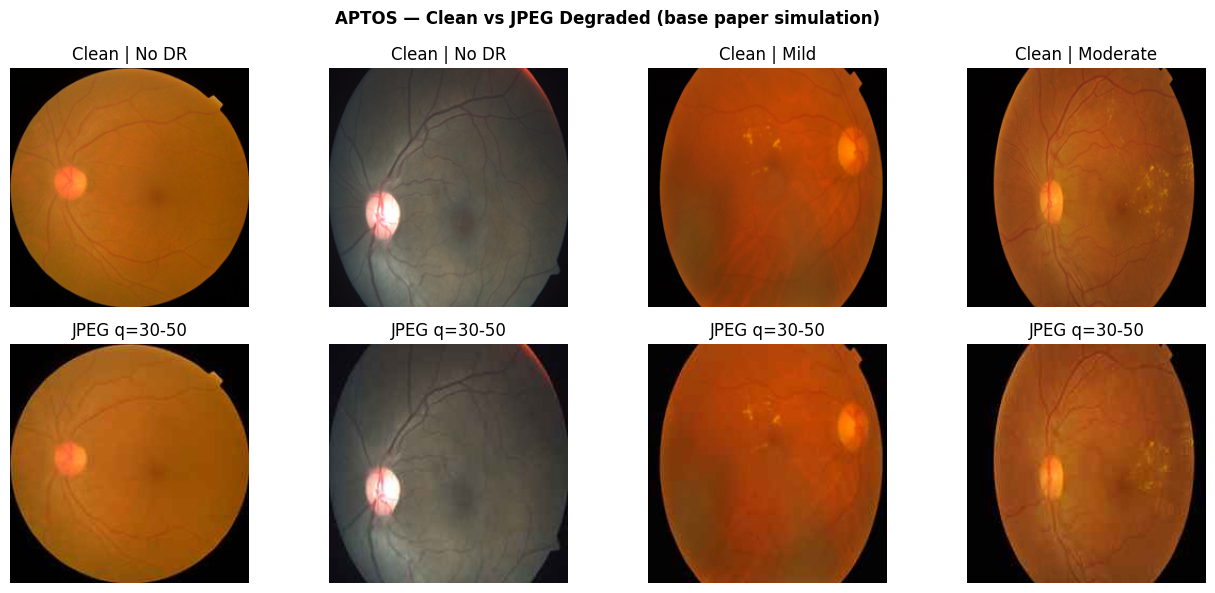

In [7]:
def jpeg_compress(img_float, quality):
    """Apply JPEG compression to a float [0,1] image.
    Converts to uint8, encode as JPEG, decode back."""
    img_uint8 = (img_float * 255).clip(0, 255).astype(np.uint8)
    pil_img   = Image.fromarray(img_uint8)
    buf       = io.BytesIO()
    pil_img.save(buf, format="JPEG", quality=quality)
    buf.seek(0)
    img_compressed = np.array(Image.open(buf)).astype(np.float32) / 255.0
    return img_compressed

def make_jpeg_degraded(X, seed=SEED):
    """Apply random JPEG compression (quality 30-50) to each image.
    Sesuai base paper: simulated under-resourced condition."""
    print(f"  Applying JPEG compression (quality {JPEG_QUALITY_MIN}-{JPEG_QUALITY_MAX})...")
    rng = np.random.default_rng(seed)
    out = np.empty_like(X)
    for i in range(len(X)):
        q = int(rng.integers(JPEG_QUALITY_MIN, JPEG_QUALITY_MAX + 1))
        out[i] = jpeg_compress(X[i], q)
    print(f"  Done. range=[{out.min():.3f},{out.max():.3f}]")
    return out

# Generate APTOS degraded (fixed seed untuk reproducibility)
print("Generating JPEG-degraded APTOS...")
X_test_unseen_degraded = make_jpeg_degraded(X_test_unseen, seed=SEED)

# Visualize
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
idx_show = np.random.RandomState(0).choice(len(X_test_unseen), 4, replace=False)
for i, idx in enumerate(idx_show):
    axes[0,i].imshow(X_test_unseen[idx])
    axes[0,i].set_title(f"Clean | {CLASS_NAMES[y_test_unseen[idx]]}"); axes[0,i].axis("off")
    axes[1,i].imshow(X_test_unseen_degraded[idx])
    axes[1,i].set_title(f"JPEG q={JPEG_QUALITY_MIN}-{JPEG_QUALITY_MAX}"); axes[1,i].axis("off")
plt.suptitle("APTOS — Clean vs JPEG Degraded (base paper simulation)", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/aptos_clean_vs_jpeg.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. TF Datasets

In [8]:
AUT = tf.data.AUTOTUNE

def make_ds(X, y, shuffle=False, seed=None):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle: ds = ds.shuffle(len(X), seed=seed)
    return ds.batch(BATCH_SIZE).prefetch(AUT)

train_ds          = make_ds(X_train, y_train, shuffle=True, seed=SEED)
test_indist_ds    = make_ds(X_test_indist, y_test_indist)
test_unseen_ds    = make_ds(X_test_unseen, y_test_unseen)
test_unseen_deg_ds= make_ds(X_test_unseen_degraded, y_test_unseen)

print(f"train          : {len(train_ds)} batches")
print(f"test in-dist   : {len(test_indist_ds)} batches")
print(f"test unseen    : {len(test_unseen_ds)} batches")
print(f"test unseen deg: {len(test_unseen_deg_ds)} batches")

train          : 1341 batches
test in-dist   : 149 batches
test unseen    : 115 batches
test unseen deg: 115 batches


## 9. Build EfficientNetB0

> `inp * 255.0` untuk handle EfficientNetB0 internal rescaling.
> Data kita [0,1], EfficientNet expects [0,255].

In [9]:
def build_model():
    base = EfficientNetB0(include_top=False, weights="imagenet",
                          input_shape=(224,224,3))
    base.trainable = False
    inp = keras.Input((224,224,3))
    x   = inp * 255.0          # scale [0,1] → [0,255] untuk EfficientNet internal rescaling
    x   = base(x, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dropout(DROPOUT)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax",
                       kernel_regularizer=regularizers.l2(L2))(x)
    return keras.Model(inp, out), base

model, base = build_model()
print(f"Total params     : {model.count_params():,}")
print(f"Trainable (S1)   : {sum(tf.size(w).numpy() for w in model.trainable_weights):,}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total params     : 4,055,976
Trainable (S1)   : 6,405


## 10. Stage 1 — Frozen Backbone

In [10]:
# SGD + momentum sesuai base paper
optimizer_s1 = keras.optimizers.SGD(learning_rate=LR, momentum=MOMENTUM)

model.compile(
    optimizer=optimizer_s1,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"])

cbs_s1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=PATIENCE,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(
        f"{MDL_DIR}/{EXPERIMENT_NAME}_s1_best.keras",
        monitor="val_loss", save_best_only=True, verbose=0),
]

# Untuk Stage 1, pakai in-distribution test sebagai validation proxy
# (base paper tidak punya explicit val set, pakai test set langsung)
print(f"Stage 1: up to {EPOCHS} epochs | SGD lr={LR} momentum={MOMENTUM}")
t0 = time.time()
h1 = model.fit(
    train_ds,
    validation_data=test_indist_ds,
    epochs=EPOCHS,
    callbacks=cbs_s1,
    verbose=1)
print(f"\nStage 1 done. {len(h1.history['loss'])} epochs | {(time.time()-t0)/60:.1f} min")

Stage 1: up to 90 epochs | SGD lr=0.001 momentum=0.9
Epoch 1/90
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 118s 50ms/step - accuracy: 0.6961 - loss: 0.8909 - val_accuracy: 0.7163 - val_loss: 0.8054 - learning_rate: 0.0010
Epoch 2/90
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.7127 - loss: 0.8355 - val_accuracy: 0.7226 - val_loss: 0.7867 - learning_rate: 0.0010
Epoch 3/90
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.7167 - loss: 0.8208 - val_accuracy: 0.7258 - val_loss: 0.7733 - learning_rate: 0.0010
Epoch 4/90
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.7207 - loss: 0.8114 - val_accuracy: 0.7327 - val_loss: 0.7743 - learning_rate: 0.0010
Epoch 5/90
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.7204 - loss: 0.8105 - val_accuracy: 0.7306 - val_loss: 0.7625 - learning_rate: 0.0010
Epoch 6/90
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.7227 - loss: 0.8054 - val_accuracy: 0.7287 - val_loss: 0.7626 - learning_rate: 0.0010
Epoch 7/90

## 11. Stage 2 — Unfreeze Top-10 Layers

In [11]:
base.trainable = True
for layer in base.layers[:-UNFREEZE_N]: layer.trainable = False
for layer in base.layers[-UNFREEZE_N:]: layer.trainable = True
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization): layer.trainable = False

# LR dikecilkan untuk fine-tuning
optimizer_s2 = keras.optimizers.SGD(learning_rate=LR/10, momentum=MOMENTUM)
model.compile(
    optimizer=optimizer_s2,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"])

cbs_s2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=PATIENCE,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-7, verbose=1),
    keras.callbacks.ModelCheckpoint(
        f"{MDL_DIR}/{EXPERIMENT_NAME}_s2_best.keras",
        monitor="val_loss", save_best_only=True, verbose=0),
]

print(f"Stage 2: up to {EPOCHS} epochs | SGD lr={LR/10} (fine-tuning)")
t0 = time.time()
h2 = model.fit(
    train_ds,
    validation_data=test_indist_ds,
    epochs=EPOCHS,
    callbacks=cbs_s2,
    verbose=1)
print(f"\nStage 2 done. {len(h2.history['loss'])} epochs | {(time.time()-t0)/60:.1f} min")

Stage 2: up to 90 epochs | SGD lr=0.0001 (fine-tuning)
Epoch 1/90
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 64s 32ms/step - accuracy: 0.7298 - loss: 0.7759 - val_accuracy: 0.7449 - val_loss: 0.7355 - learning_rate: 1.0000e-04
Epoch 2/90
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.7304 - loss: 0.7695 - val_accuracy: 0.7430 - val_loss: 0.7321 - learning_rate: 1.0000e-04
Epoch 3/90
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.7334 - loss: 0.7672 - val_accuracy: 0.7476 - val_loss: 0.7300 - learning_rate: 1.0000e-04
Epoch 4/90
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.7332 - loss: 0.7644 - val_accuracy: 0.7470 - val_loss: 0.7277 - learning_rate: 1.0000e-04
Epoch 5/90
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.7339 - loss: 0.7623 - val_accuracy: 0.7470 - val_loss: 0.7271 - learning_rate: 1.0000e-04
Epoch 6/90
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.7349 - loss: 0.7600 - val_accuracy: 0.7501 - val_loss: 0.7249 - learning_ra

KeyboardInterrupt: 

## 12. Save Model + Training Curves

In [ ]:
model.save(f"{MDL_DIR}/{EXPERIMENT_NAME}_final.keras")

s1_len = len(h1.history["loss"])
ep     = list(range(1, s1_len + len(h2.history["loss"]) + 1))
hist   = {
    "loss":         h1.history["loss"]         + h2.history["loss"],
    "val_loss":     h1.history["val_loss"]     + h2.history["val_loss"],
    "accuracy":     h1.history["accuracy"]     + h2.history["accuracy"],
    "val_accuracy": h1.history["val_accuracy"] + h2.history["val_accuracy"],
    "stage": ["s1"]*s1_len + ["s2"]*len(h2.history["loss"])
}
pd.DataFrame(hist).assign(epoch=ep).to_csv(f"{LOG_DIR}/training_history.csv", index=False)

fig, ax = plt.subplots(1,2,figsize=(13,5))
ax[0].plot(ep,hist["accuracy"],     label="Train"); ax[0].plot(ep,hist["val_accuracy"],"--",label="Val")
ax[0].axvline(s1_len,color="gray",ls=":",lw=1.5,label="S1→S2"); ax[0].set_title("Accuracy")
ax[0].legend(); ax[0].grid(alpha=.3); ax[0].set_xlabel("Epoch")
ax[1].plot(ep,hist["loss"],     label="Train"); ax[1].plot(ep,hist["val_loss"],"--",label="Val")
ax[1].axvline(s1_len,color="gray",ls=":",lw=1.5,label="S1→S2"); ax[1].set_title("Loss")
ax[1].legend(); ax[1].grid(alpha=.3); ax[1].set_xlabel("Epoch")
plt.suptitle(f"Centralized (Base Paper Format) — {MODEL_NAME}"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/training_curves.png", dpi=300, bbox_inches="tight"); plt.show()

## 13. Evaluate — 3 Test Conditions

Sesuai base paper evaluation:
1. **In-distribution** — DDR + EyePACS test split
2. **Unseen clean** — APTOS (clean)
3. **Unseen degraded** — APTOS (JPEG compressed, simulated under-resourced)

In [ ]:
print("Predicting in-distribution test...")
yp_indist = model.predict(test_indist_ds, verbose=1)
yd_indist = np.argmax(yp_indist, 1)

print("\nPredicting APTOS clean (unseen)...")
yp_unseen = model.predict(test_unseen_ds, verbose=1)
yd_unseen = np.argmax(yp_unseen, 1)

print("\nPredicting APTOS degraded (unseen + JPEG)...")
yp_unseen_deg = model.predict(test_unseen_deg_ds, verbose=1)
yd_unseen_deg = np.argmax(yp_unseen_deg, 1)

## 14. Metrics

In [ ]:
def metrics(yt, yp, yprob, label=""):
    a = accuracy_score(yt, yp)
    p,r,f,_ = precision_recall_fscore_support(yt, yp, average="macro", zero_division=0)
    yb = label_binarize(yt, classes=np.arange(NUM_CLASSES))
    try: au = roc_auc_score(yb, yprob, multi_class="ovr", average="macro")
    except: au = float("nan")
    q = cohen_kappa_score(yt, yp, weights="quadratic")
    return dict(label=label, accuracy=float(a), precision_macro=float(p),
                recall_macro=float(r), f1_macro=float(f),
                auc_roc=float(au), qwk=float(q))

MKEYS = ["accuracy","precision_macro","recall_macro","f1_macro","auc_roc","qwk"]

m_indist     = metrics(y_test_indist,  yd_indist,     yp_indist,     "In-Distribution (DDR+EyePACS)")
m_unseen     = metrics(y_test_unseen,  yd_unseen,     yp_unseen,     "Unseen Clean (APTOS)")
m_unseen_deg = metrics(y_test_unseen,  yd_unseen_deg, yp_unseen_deg, "Unseen Degraded (APTOS+JPEG)")

print(f"{'Metric':<18} {'In-Dist':>10} {'Unseen':>10} {'Unseen+JPEG':>12}")
print("-"*52)
for k in MKEYS:
    print(f"{k:<18} {m_indist[k]:>10.4f} {m_unseen[k]:>10.4f} {m_unseen_deg[k]:>12.4f}")

# Generalizability drop (sesuai base paper: clean vs degraded di APTOS)
print(f"\n{'Generalizability Drop (Unseen clean - degraded)':}")
print("-"*52)
for k in MKEYS:
    drop = m_unseen[k] - m_unseen_deg[k]
    print(f"  {k:<18}: {drop:+.4f}")

## 15. Per-Client Breakdown (In-Distribution)

In [ ]:
print(f"{'Client':<10} {'N':>5}  {'Acc':>7} {'F1':>7} {'QWK':>7}")
print("-"*42)
for cl, yte_, yp_, yprob_ in [
    ("DDR",     yte_d, yd_indist[:len(yte_d)], yp_indist[:len(yte_d)]),
    ("EyePACS", yte_e, yd_indist[len(yte_d):], yp_indist[len(yte_d):])]:
    m = metrics(yte_, yp_, yprob_)
    print(f"{cl:<10} {len(yte_):>5,}  {m['accuracy']:>7.4f} {m['f1_macro']:>7.4f} {m['qwk']:>7.4f}")

## 16. Confusion Matrices

In [ ]:
SN = ["NoDR","Mild","Mod.","Sev.","Prol."]
cms = [
    (confusion_matrix(y_test_indist,  yd_indist,     labels=np.arange(NUM_CLASSES)), "In-Distribution"),
    (confusion_matrix(y_test_unseen,  yd_unseen,     labels=np.arange(NUM_CLASSES)), "Unseen Clean"),
    (confusion_matrix(y_test_unseen,  yd_unseen_deg, labels=np.arange(NUM_CLASSES)), "Unseen+JPEG"),
]

fig, axes = plt.subplots(1,3,figsize=(18,6))
for ax,( cm, title) in zip(axes, cms):
    im = ax.imshow(cm, cmap="Blues"); plt.colorbar(im, ax=ax, fraction=.046)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(SN, rotation=30, ha="right"); ax.set_yticklabels(SN)
    th = cm.max()/2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j,i,str(cm[i,j]),ha="center",va="center",fontsize=8,
                    color="white" if cm[i,j]>th else "black")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
plt.suptitle(f"Centralized Base Paper — Confusion Matrices", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/confusion_matrices.png", dpi=300, bbox_inches="tight"); plt.show()

## 17. Generalizability Visualization

In [ ]:
MLABELS = ["Accuracy","Precision","Recall","F1","AUC-ROC","QWK"]
x = np.arange(len(MLABELS)); w = .25

v_ind = [m_indist[k]     for k in MKEYS]
v_uns = [m_unseen[k]     for k in MKEYS]
v_deg = [m_unseen_deg[k] for k in MKEYS]

fig, ax = plt.subplots(figsize=(13,5))
ax.bar(x - w,   v_ind, w, label="In-Distribution",   color="#1565C0", alpha=.85)
ax.bar(x,       v_uns, w, label="Unseen Clean",       color="#2E7D32", alpha=.85)
ax.bar(x + w,   v_deg, w, label="Unseen+JPEG",        color="#E53935", alpha=.85)
for i,(a,b,c_) in enumerate(zip(v_ind,v_uns,v_deg)):
    ax.text(i-w,   a+.01, f"{a:.3f}", ha="center", fontsize=7)
    ax.text(i,     b+.01, f"{b:.3f}", ha="center", fontsize=7)
    ax.text(i+w,   c_+.01,f"{c_:.3f}",ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(MLABELS); ax.set_ylim(0,1.15)
ax.set_title("Centralized — In-Dist vs Unseen Clean vs Unseen+JPEG (Base Paper Format)")
ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/generalizability_comparison.png", dpi=300, bbox_inches="tight"); plt.show()

## 18. Save Results

In [ ]:
res = {
    "experiment": EXPERIMENT_NAME, "model": MODEL_NAME,
    "paradigm": "Centralized", "format": "base_paper",
    "train_on": TRAIN_CLIENTS, "unseen": UNSEEN_CLIENT,
    "n_train": int(len(y_train)),
    "n_test_indist": int(len(y_test_indist)),
    "n_test_unseen": int(len(y_test_unseen)),
    "metrics_indist": m_indist,
    "metrics_unseen_clean": m_unseen,
    "metrics_unseen_degraded": m_unseen_deg,
    "generalizability_drop": {k: float(m_unseen[k]-m_unseen_deg[k]) for k in MKEYS},
    "config": dict(seed=SEED, lr=LR, momentum=MOMENTUM, batch=BATCH_SIZE,
                   epochs_max=EPOCHS, patience=PATIENCE,
                   jpeg_quality_min=JPEG_QUALITY_MIN,
                   jpeg_quality_max=JPEG_QUALITY_MAX,
                   unfreeze_n=UNFREEZE_N)
}
with open(f"{LOG_DIR}/results.json","w") as f: json.dump(res,f,indent=2)

row = {"experiment":EXPERIMENT_NAME,"paradigm":"Centralized_BasePaper","model":MODEL_NAME}
row.update({f"indist_{k}":m_indist[k] for k in MKEYS})
row.update({f"unseen_{k}":m_unseen[k] for k in MKEYS})
row.update({f"unseen_deg_{k}":m_unseen_deg[k] for k in MKEYS})
pd.DataFrame([row]).to_csv(f"{LOG_DIR}/summary_row.csv", index=False)
print(f"Saved to: {RES}")

print("\n" + "="*60)
print(f"  CENTRALIZED BASE PAPER FORMAT — DONE")
print("="*60)
print(f"  Train: {len(y_train):,} ({' + '.join(TRAIN_CLIENTS)})")
print(f"  In-Dist  | Acc:{m_indist['accuracy']:.4f}  F1:{m_indist['f1_macro']:.4f}  QWK:{m_indist['qwk']:.4f}")
print(f"  Unseen   | Acc:{m_unseen['accuracy']:.4f}  F1:{m_unseen['f1_macro']:.4f}  QWK:{m_unseen['qwk']:.4f}")
print(f"  +JPEG    | Acc:{m_unseen_deg['accuracy']:.4f}  F1:{m_unseen_deg['f1_macro']:.4f}  QWK:{m_unseen_deg['qwk']:.4f}")
print(f"  Drop     | Acc:{m_unseen['accuracy']-m_unseen_deg['accuracy']:+.4f}  F1:{m_unseen['f1_macro']-m_unseen_deg['f1_macro']:+.4f}")
print("="*60)